# Task 1
Потрібно проаналізувати дані транзакцій інтернет-магазину та візуалізувати розподіл сум замовлень. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Завантажте дані з CSV у таблицю.

* Виведіть перші рядки та інформацію про стовпці.
* Визначте кількість пропусків за кожним стовпчиком.
* Побудуйте зведення за "amount": кількість, середнє, медіана, мінімум, максимум, квартилі та перцентилі.
* Побудуйте гістограму "amount" і коробчату діаграму.
* Видаліть пропуски в "amount" і повторіть розрахунок зведення.
* Виведіть усі результати та графіки.

In [1]:
import pandas as pd

In [2]:
sales = pd.read_csv('sales.csv').dropna()
print(sales)

   ID             Товар       Категорія   Ціна  Кількість  Продано
0   1       Ноутбук Pro     Електроніка  45000        5.0      3.0
1   2  Мишка бездротова       Аксесуари   1200       50.0     22.0
3   4       Монітор 27"       Периферія  12000       10.0     10.0
4   5        Смартфон X         Гаджети  28000       15.0      8.0
5   6     Навушники ANC           Аудіо   5500       30.0     21.0
6   7  Принтер лазерний  Офісна техніка   8000        4.0      1.0
8   9     Веб-камера 4K       Периферія   4100       12.0     11.0


In [3]:
empties = sales.isnull().sum()
print(empties)

ID           0
Товар        0
Категорія    0
Ціна         0
Кількість    0
Продано      0
dtype: int64


In [4]:
def stat(data):
    print('Sold: %d pcs\nAvarage sales: %.1f pcs/name\nMedian sales: %d pcs\nMinimum sales: %d\nMaximum sales: %d\nQuartiles:\n%s\n90-th percentile: %.1f' %
    (
        data['Продано'].sum(),
        data['Продано'].mean(),
        data['Продано'].median(),
        data['Продано'].min(),
        data['Продано'].max(),
        data['Продано'].quantile([0.25, 0.5, 0.75]),
        data['Продано'].quantile(0.90),
    ))
stat(sales)

Sold: 76 pcs
Avarage sales: 10.9 pcs/name
Median sales: 10 pcs
Minimum sales: 1
Maximum sales: 22
Quartiles:
0.25     5.5
0.50    10.0
0.75    16.0
Name: Продано, dtype: float64
90-th percentile: 21.4


In [5]:
import matplotlib.pyplot as plt

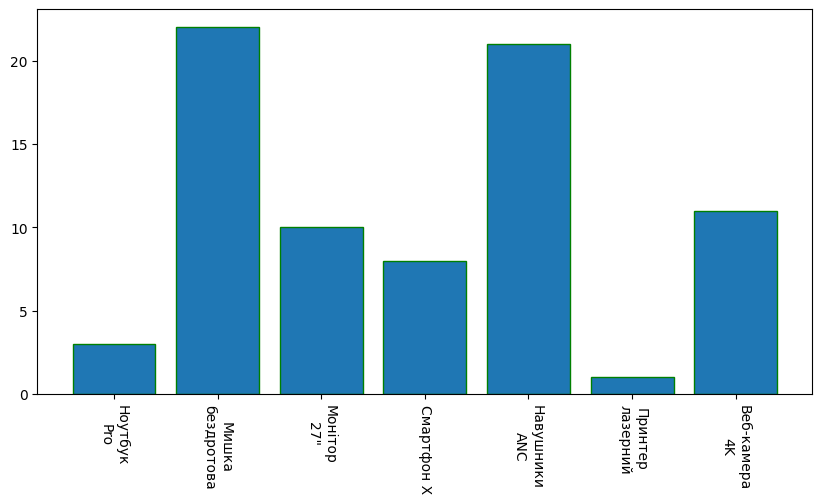

In [6]:
from textwrap import fill
fig, ax = plt.subplots(figsize=(10, 5))
plt.bar([fill(name, width=10) for name in sales['Товар']], sales['Продано'], edgecolor='green')
plt.xticks(rotation=270)
plt.style.use('ggplot')
plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'color'

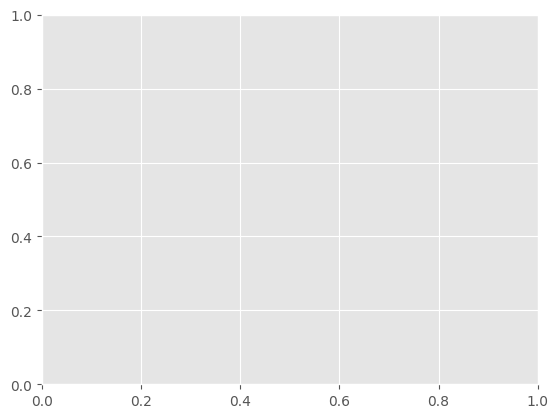

In [12]:
fig, ax = plt.subplots()
ax.boxplot(sales['Продано'].dropna(), color='red')
plt.style.use('seaborn-v0_8')
plt.show()

In [ ]:
stat(sales)
print('\n\n\n')
stat(sales.dropna())

# Task 2
Потрібно змоделювати вибірку розмірів замовлень із додаванням викидів і провести базовий статистичний аналіз. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Створіть одновимірний масив додатних чисел і додайте кілька аномально великих значень.

* Перетворіть масив на таблицю з одним стовпчиком.
* Розрахуйте середнє, медіану, стандартне відхилення, IQR і MAD, коефіцієнти асиметрії та ексцесу.
* Побудуйте гістограму розподілу та коробчату діаграму.
* Визначте частку спостережень, що виходять за "вуса" коробчастої діаграми.
* Виведіть числові результати та графіки.

In [10]:
import pandas as pd
data = pd.DataFrame({'Продано': [*sales['Продано'].dropna(), 42]})

In [11]:
data

,Продано
0,3.0
1,22.0
2,10.0
3,8.0
4,21.0
5,1.0
6,11.0
7,42.0


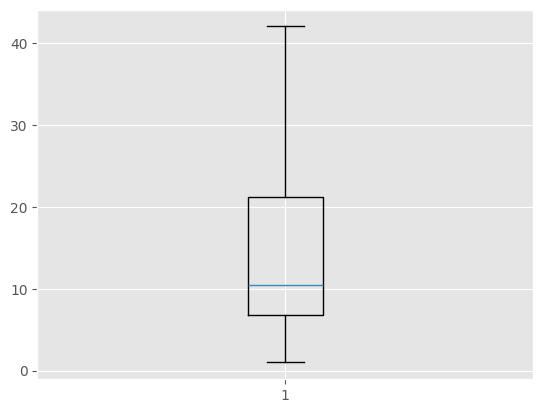

In [13]:
fig, ax = plt.subplots()
ax.boxplot(data)
plt.show()

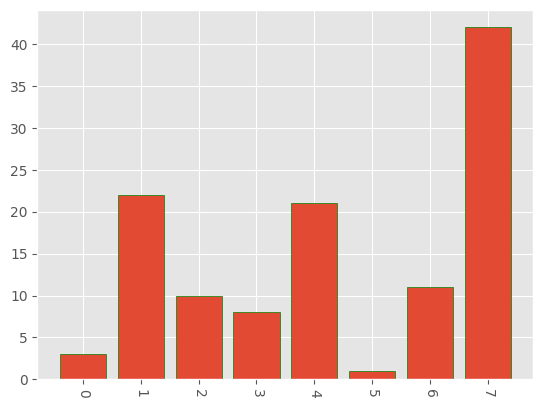

In [28]:
import numpy as np
fig, ax = plt.subplots()
plt.bar([str(i) for i in range(len(data))], data['Продано'], edgecolor='green')
plt.xticks(rotation=270)
plt.style.use('ggplot')
plt.show()

In [62]:
Q1 = data['Продано'].quantile(0.25)
Q3 = data['Продано'].quantile(0.75)
avg = data['Продано'].mean()
mad = (data['Продано'] - avg).abs().mean()
IQR = Q3 - Q1
emission = data[(data['Продано'] < Q1 - 1.5 * IQR) | (data['Продано'] > Q3 + 1.5 * IQR)]

print((
    'average quantity products per sale: %.1f pcs\n' +
    'Standart quantity deflection of sales: %.1f pcs\n'+
    'Absolute average deflection of quantity sales: %.1f pcs\n'+
    'Median sales: %.1f pcs\n' +
    'Interquantile range: %.1f\n' +
    'Bias coefficient (or asymmetry): %.1f\n' +
    'Kurtosis coefficient: %.1f\n' +
    'Emission coefficient: %s\n'
) % (
    avg,
    data['Продано'].std(),
    mad,
    data['Продано'].median(),
    IQR,
    data['Продано'].skew(),
    data['Продано'].kurtosis(),
    emission.index.step
))

average quantity products per sale: 14.8 pcs
Standart quantity deflection of sales: 13.3 pcs
Absolute average deflection of quantity sales: 10.2 pcs
Median sales: 10.5 pcs
Interquantile range: 14.5
Bias coefficient (or asymmetry): 1.3
Kurtosis coefficient: 1.8
Emission coefficient: 1

